In [3]:
from google.colab import files
uploaded = files.upload()

Saving List of Orders.csv to List of Orders (1).csv
Saving Order Details.csv to Order Details (1).csv
Saving Sales target.csv to Sales target (1).csv


In [4]:
import pandas as pd

orders = pd.read_csv('/content/List of Orders.csv')
details = pd.read_csv('/content/Order Details.csv')
targets = pd.read_csv('/content/Sales target.csv')

print("Orders Dataset")
display(orders.head())

print("Order Details Dataset")
display(details.head())

print("Sales Target Dataset")
display(targets.head())


Orders Dataset


,Order ID,Order Date,CustomerName,State,City
0,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad
1,B-25602,01-04-2018,Pearl,Maharashtra,Pune
2,B-25603,03-04-2018,Jahan,Madhya Pradesh,Bhopal
3,B-25604,03-04-2018,Divsha,Rajasthan,Jaipur
4,B-25605,05-04-2018,Kasheen,West Bengal,Kolkata


Order Details Dataset


,Order ID,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,1275.0,-1148.0,7,Furniture,Bookcases
1,B-25601,66.0,-12.0,5,Clothing,Stole
2,B-25601,8.0,-2.0,3,Clothing,Hankerchief
3,B-25601,80.0,-56.0,4,Electronics,Electronic Games
4,B-25602,168.0,-111.0,2,Electronics,Phones


Sales Target Dataset


,Month of Order Date,Category,Target
0,Apr-18,Furniture,10400.0
1,May-18,Furniture,10500.0
2,Jun-18,Furniture,10600.0
3,Jul-18,Furniture,10800.0
4,Aug-18,Furniture,10900.0


In [5]:
print(orders.info())
print(details.info())
print(targets.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      500 non-null    object
 1   Order Date    500 non-null    object
 2   CustomerName  500 non-null    object
 3   State         500 non-null    object
 4   City          500 non-null    object
dtypes: object(5)
memory usage: 22.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      1500 non-null   object 
 1   Amount        1500 non-null   float64
 2   Profit        1500 non-null   float64
 3   Quantity      1500 non-null   int64  
 4   Category      1500 non-null   object 
 5   Sub-Category  1500 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 70.4+ KB
None
<class 'pandas.core.frame.DataFrame'>


In [6]:
print(orders.isnull().sum())

print(details.isnull().sum())

print(targets.isnull().sum())

Order ID        60
Order Date      60
CustomerName    60
State           60
City            60
dtype: int64
Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
dtype: int64
Month of Order Date    0
Category               0
Target                 0
dtype: int64


In [7]:
df = pd.merge(orders, details, on='Order ID')

df.head()

,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad,1275.0,-1148.0,7,Furniture,Bookcases
1,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad,66.0,-12.0,5,Clothing,Stole
2,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad,8.0,-2.0,3,Clothing,Hankerchief
3,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad,80.0,-56.0,4,Electronics,Electronic Games
4,B-25602,01-04-2018,Pearl,Maharashtra,Pune,168.0,-111.0,2,Electronics,Phones


In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [9]:
df['Order Date'].head()

,Order Date
0,2018-04-01
1,2018-04-01
2,2018-04-01
3,2018-04-01
4,2018-04-01


In [10]:
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

df.head()

,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category,Month,Year
0,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,1275.0,-1148.0,7,Furniture,Bookcases,4,2018
1,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,66.0,-12.0,5,Clothing,Stole,4,2018
2,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,8.0,-2.0,3,Clothing,Hankerchief,4,2018
3,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,80.0,-56.0,4,Electronics,Electronic Games,4,2018
4,B-25602,2018-04-01,Pearl,Maharashtra,Pune,168.0,-111.0,2,Electronics,Phones,4,2018


In [11]:
total_sales = df['Amount'].sum()
total_profit = df['Profit'].sum()
total_quantity = df['Quantity'].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity Sold:", total_quantity)

Total Sales: 431502.0
Total Profit: 23955.0
Total Quantity Sold: 5615


In [12]:
category_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

print(category_sales)

Category
Electronics    165267.0
Clothing       139054.0
Furniture      127181.0
Name: Amount, dtype: float64


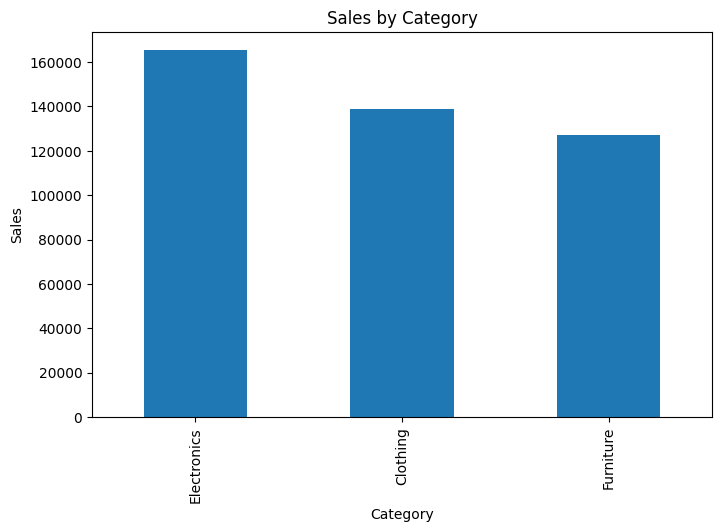

In [13]:
import matplotlib.pyplot as plt

category_sales.plot(kind='bar', figsize=(8,5))

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

In [14]:
monthly_sales = df.groupby('Month')['Amount'].sum()

print(monthly_sales)

Month
1     61439.0
2     38424.0
3     58937.0
4     32726.0
5     28545.0
6     23658.0
7     12966.0
8     30899.0
9     26628.0
10    31615.0
11    48086.0
12    37579.0
Name: Amount, dtype: float64


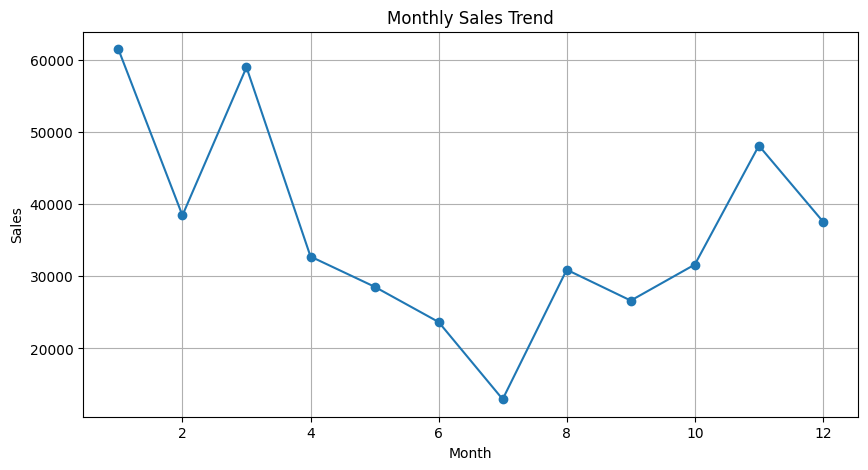

In [15]:
monthly_sales.plot(kind='line', figsize=(10,5), marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [16]:
state_sales = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head()

print(state_sales)

State
Madhya Pradesh    105140.0
Maharashtra        95348.0
Delhi              22531.0
Uttar Pradesh      22359.0
Rajasthan          21149.0
Name: Amount, dtype: float64


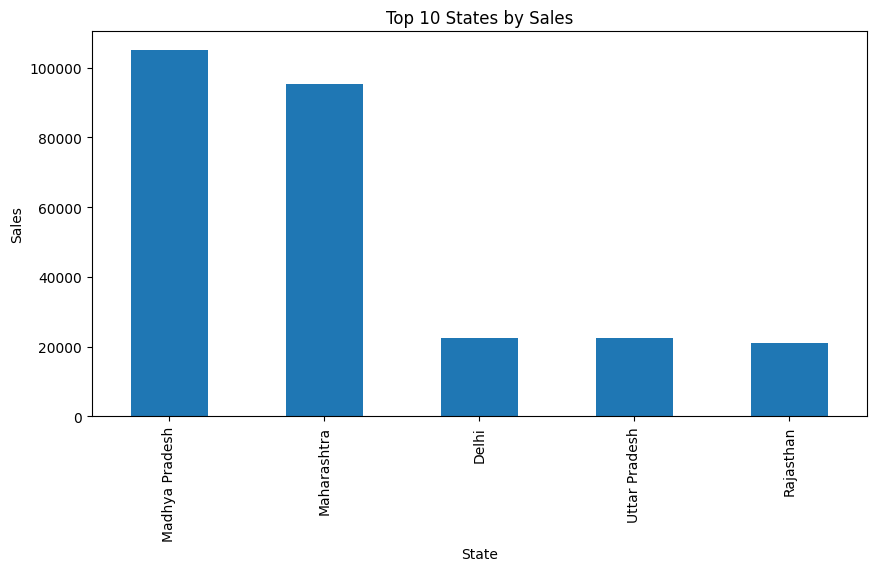

In [17]:
state_sales.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.show()

In [18]:
profit_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

print(profit_category)

Category
Clothing       11163.0
Electronics    10494.0
Furniture       2298.0
Name: Profit, dtype: float64


In [19]:
top_customers = df.groupby('CustomerName')['Amount'].sum().sort_values(ascending=False).head()

print(top_customers)

CustomerName
Yaanvi      9177.0
Pooja       9030.0
Abhishek    8135.0
Surabhi     6889.0
Soumya      6869.0
Name: Amount, dtype: float64


In [20]:
df['Profit Margin'] = (df['Profit'] / df['Amount']) * 100

df.head()

,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category,Month,Year,Profit Margin
0,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,1275.0,-1148.0,7,Furniture,Bookcases,4,2018,-90.039216
1,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,66.0,-12.0,5,Clothing,Stole,4,2018,-18.181818
2,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,8.0,-2.0,3,Clothing,Hankerchief,4,2018,-25.000000
3,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,80.0,-56.0,4,Electronics,Electronic Games,4,2018,-70.000000
4,B-25602,2018-04-01,Pearl,Maharashtra,Pune,168.0,-111.0,2,Electronics,Phones,4,2018,-66.071429


In [21]:
margin_category = df.groupby('Category')['Profit Margin'].mean()

print(margin_category)

Category
Clothing       4.132921
Electronics   -0.622928
Furniture     -6.788811
Name: Profit Margin, dtype: float64


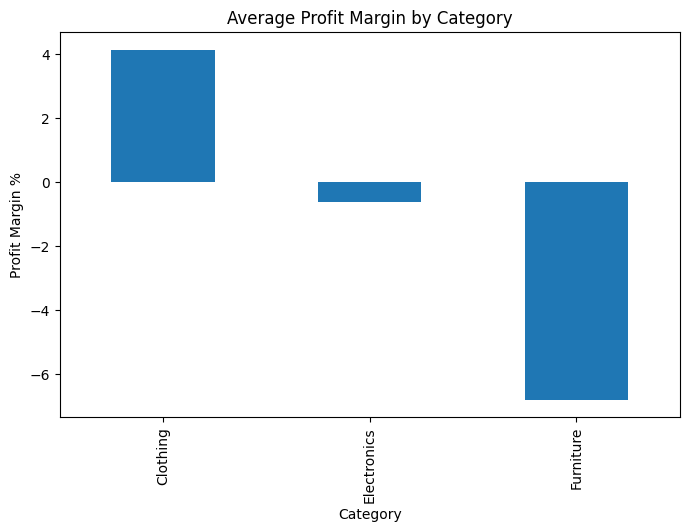

In [22]:
margin_category.plot(kind='bar', figsize=(8,5))

plt.title("Average Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin %")

plt.show()

In [23]:
loss_products = df[df['Profit'] < 0]

loss_products[['Category', 'Sub-Category', 'Profit']].head()

,Category,Sub-Category,Profit
0,Furniture,Bookcases,-1148.0
1,Clothing,Stole,-12.0
2,Clothing,Hankerchief,-2.0
3,Electronics,Electronic Games,-56.0
4,Electronics,Phones,-111.0


In [24]:
top_products = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)

print(top_products)

Sub-Category
Printers       5964.0
Bookcases      4888.0
Accessories    3559.0
Trousers       2847.0
Stole          2559.0
Phones         2207.0
Hankerchief    2098.0
T-shirt        1500.0
Shirt          1131.0
Furnishings     844.0
Name: Profit, dtype: float64


In [26]:
targets.head()

,Month of Order Date,Category,Target
0,Apr-18,Furniture,10400.0
1,May-18,Furniture,10500.0
2,Jun-18,Furniture,10600.0
3,Jul-18,Furniture,10800.0
4,Aug-18,Furniture,10900.0


In [27]:
correlation = df[['Amount', 'Profit', 'Quantity']].corr()

print(correlation)

            Amount    Profit  Quantity
Amount    1.000000  0.242045  0.352052
Profit    0.242045  1.000000  0.002441
Quantity  0.352052  0.002441  1.000000


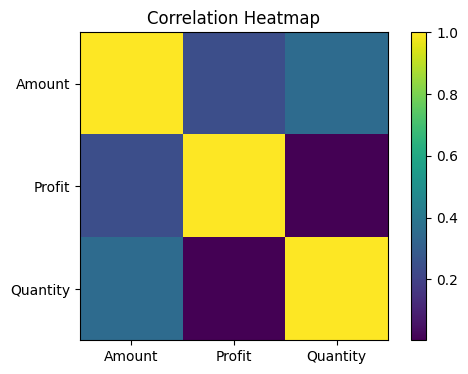

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

In [30]:
customer_sales = df.groupby('CustomerName')['Amount'].sum().reset_index()

customer_sales.head(20)

,CustomerName,Amount
0,Aakanksha,74.0
1,Aarushi,4701.0
2,Aashna,1931.0
3,Aastha,3276.0
4,Aayush,556.0
5,Aayushi,689.0
6,Abhijeet,5691.0
7,Abhijit,78.0
8,Abhishek,8135.0
9,Adhvaita,193.0


In [31]:
from sklearn.cluster import KMeans

X = customer_sales[['Amount']]

kmeans = KMeans(n_clusters=3, random_state=42)

customer_sales['Cluster'] = kmeans.fit_predict(X)

customer_sales.head()

,CustomerName,Amount,Cluster
0,Aakanksha,74.0,0
1,Aarushi,4701.0,1
2,Aashna,1931.0,2
3,Aastha,3276.0,2
4,Aayush,556.0,0


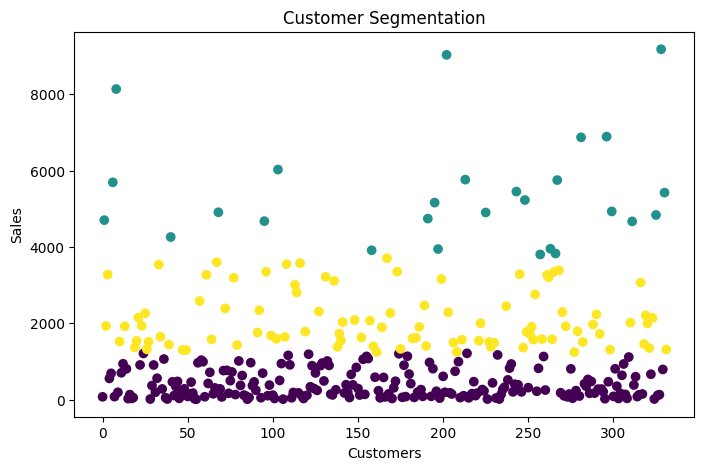

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(customer_sales.index, customer_sales['Amount'],
            c=customer_sales['Cluster'])

plt.title("Customer Segmentation")
plt.xlabel("Customers")
plt.ylabel("Sales")

plt.show()

In [33]:
monthly_data = df.groupby('Month')['Amount'].sum().reset_index()

monthly_data

,Month,Amount
0,1,61439.0
1,2,38424.0
2,3,58937.0
3,4,32726.0
4,5,28545.0
5,6,23658.0
6,7,12966.0
7,8,30899.0
8,9,26628.0
9,10,31615.0


In [34]:
X = monthly_data[['Month']]
y = monthly_data['Amount']


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [36]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")


Model Trained Successfully


In [38]:
predictions = model.predict(X_test)

print(predictions)

[25721.94692737 27090.88826816 39411.3603352 ]


In [39]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)

print("R2 Score:", score)

R2 Score: -1.25343850459676


In [40]:
future_months = [[13], [14], [15]]

future_sales = model.predict(future_months)

print(future_sales)

[22984.06424581 21615.12290503 20246.18156425]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


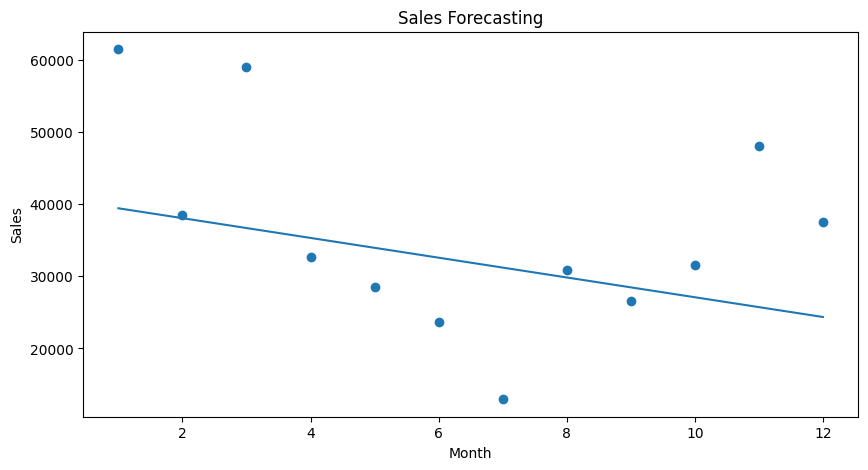

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(X, y)

plt.plot(X, model.predict(X))

plt.title("Sales Forecasting")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [42]:
df.to_csv("cleaned_ecommerce_data.csv", index=False)

print("Dataset Exported Successfully")

Dataset Exported Successfully


In [43]:
from google.colab import files

files.download("cleaned_ecommerce_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>